# Dataset

In [1]:
import torch
from torch import nn
from torch.random import manual_seed
manual_seed(513)

from modules.latentAE.dataset import SignalDataset
from modules.preprocess import AutoCorrPeak, XCorrPeak
from modules.augmentation import AWGN, MP
from modules.generators import SinSweepGen,LFMSweepGen, BPSKGen, SinSweepMultiToneGen, WeirdGen

from modules.latentAE.model import Autoencoder, Encoder, Decoder, calc_num_params
from modules.latentAE.train import ConvolutionalAutoencoderTrainer



# ===================== TRANSFORM =============================
peak_width_factor=50

class Transform(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.awgn = AWGN()
        self.mp = MP()
        self.xcorr_peak_extractor = XCorrPeak(peak_width_factor=peak_width_factor)
        self.inorm = nn.InstanceNorm1d(2)
        
    def forward(self, x):
        y = self.awgn(x)
        y = self.mp(y)
        y = self.xcorr_peak_extractor(y, x)
        y = self.inorm(y)
        return y
    
class TransformTest(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.awgn = AWGN()
        self.mp = MP()
        self.xcorr_peak_extractor = XCorrPeak(peak_width_factor=peak_width_factor)
        self.inorm = nn.InstanceNorm1d(2)
        
    def forward(self, x):
        y = self.awgn(x)
        y = self.mp(y)
        y = self.xcorr_peak_extractor(y, x)
        y = self.inorm(y)
        return y
    
# gen_objs_train = [SinSweepGen(), SinSweepMultiToneGen(), LFMSweepGen()]
# gen_objs_train = [SinSweepGen(), SinSweepMultiToneGen()]
# gen_objs_train = [SinSweepGen(), BPSKGen(), LFMSweepGen()]
# gen_objs_train = [BPSKGen(), SinSweepGen(), LFMSweepGen(), SinSweepMultiToneGen(), WeirdGen()]
gen_objs_train = [BPSKGen(), SinSweepGen(), LFMSweepGen(), SinSweepMultiToneGen()]

gen_objs_test = [BPSKGen(), SinSweepGen(), LFMSweepGen(), SinSweepMultiToneGen()]


train_ds = SignalDataset(gen_objs_train, transform=Transform())
val_ds = SignalDataset(gen_objs_train, transform=Transform())
test_ds = SignalDataset(gen_objs_test, transform=TransformTest())

# Model

In [2]:
#  training model
%matplotlib inline



# Check if CUDA is available and set the device
if torch.cuda.is_available():
    device = torch.device("cuda")  # Use the first CUDA device
else:
    device = torch.device("cpu")   # Fallback to CPU

# architecture params
params = {
    "in_channels": 2,
    "out_channels": 64,
    "kernel_size": 15,
    "padding": 10,
    "output_padding": 2,
    "dilation": 1,
    "stride": 3,
}

model = ConvolutionalAutoencoderTrainer(
    Autoencoder(
        Encoder(
            in_channels=params["in_channels"],
            out_channels=params["out_channels"]//4, 
            kernel_size=params["kernel_size"],
            padding=params["padding"],
            dilation=params["dilation"],
            stride=params["stride"]
        ),
        Decoder(
            in_channels=params["in_channels"],
            out_channels=params["out_channels"]//4, 
            kernel_size=params["kernel_size"],
            padding=params["padding"],
            dilation=params["dilation"],
            stride=params["stride"],
            output_padding=params["output_padding"],
        ),
        device=device
    ),
    device=device
)
# out channels weird, thats the way it is gonna have to fix

### Load Pretrained

In [3]:
# import torch

ckpt_path = [
    # './ae_model_checkpoints/exp1_ae_model_2024-10-18_ckpt_270000.pt',  # exp 1 - first train loop
    # './ae_model_checkpoints/exp2_ae_model_2024-10-18_ckpt_45000.pt', # exp 2 - second train loop
    # './ae_model_checkpoints/exp3_ae_model_2024-10-20_ckpt_45000.pt'  # exp 3 - latent meddling
    './ae_model_checkpoints/exp4_ae_model_2024-10-20_ckpt_40000.pt'  # exp 4 - latent meddling
]

model.load_checkpoint(ckpt_path)

# Train Loop

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

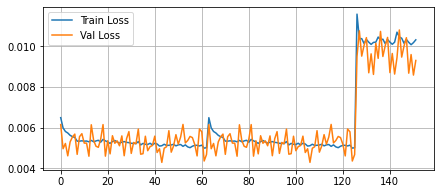

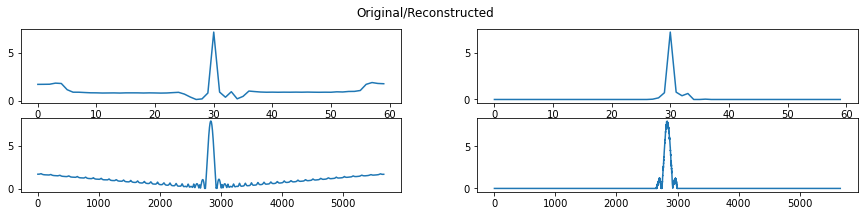

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

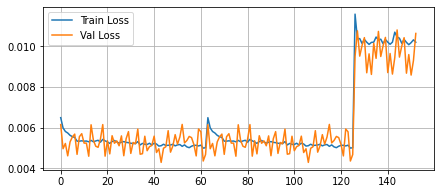

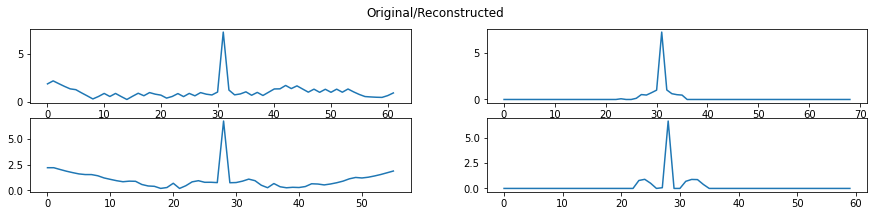

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

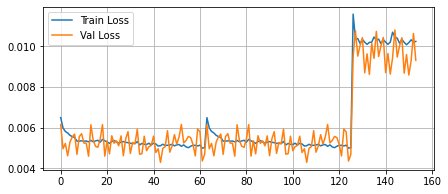

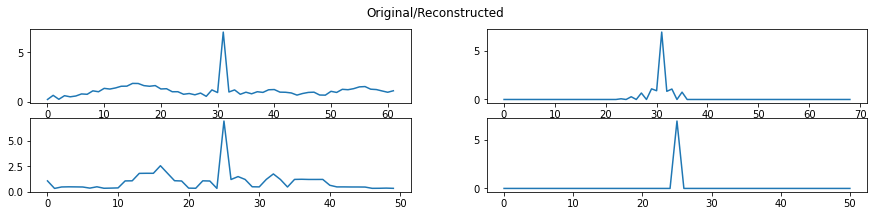

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

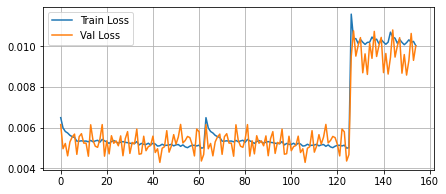

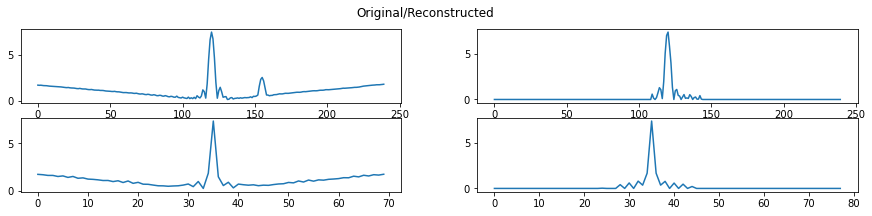

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

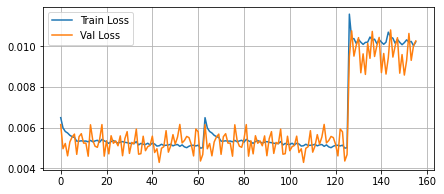

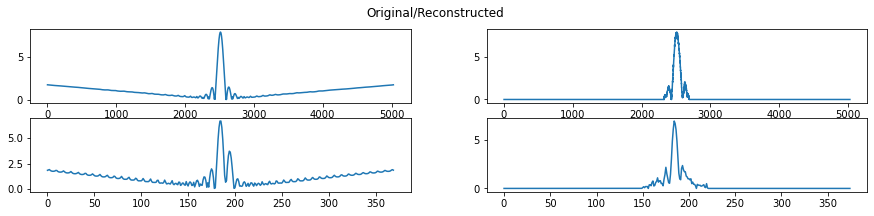

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

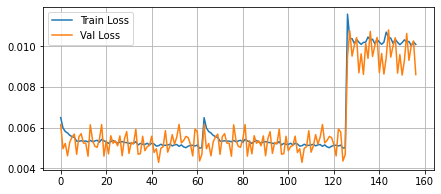

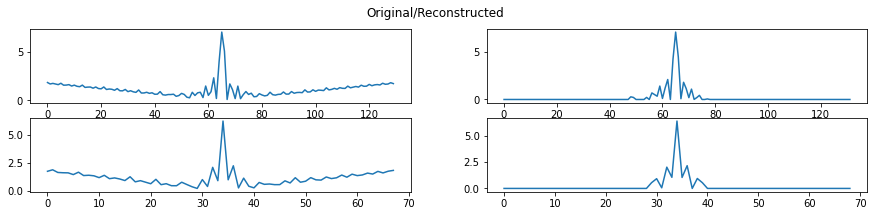

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

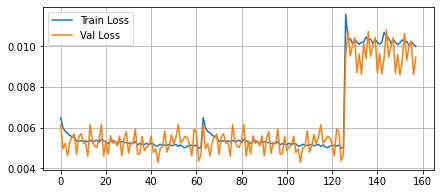

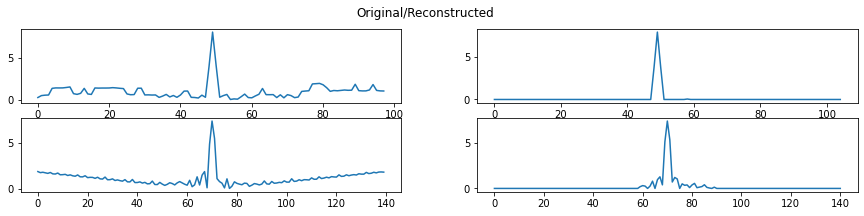

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

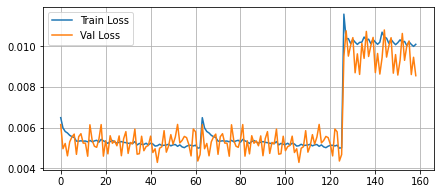

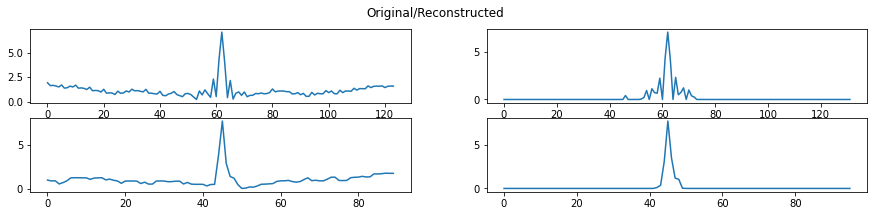

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

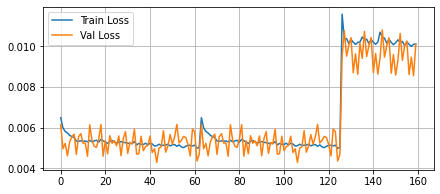

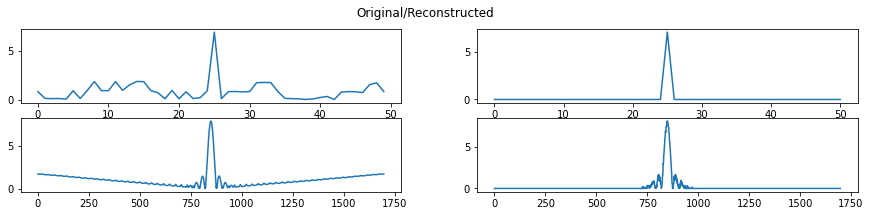

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

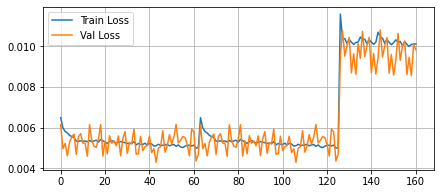

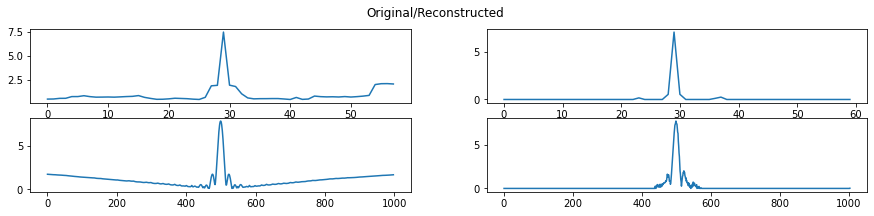

In [4]:
import json
from datetime import datetime


# training params
params.update({
    "lr": 5e-5,
    "epochs": 10,
    "train_samples": 5000,
    "latent_loss_factor": 1,
    "val_samples": 100,
    "loss": nn.L1Loss(),
    "exp_name": "exp5",
})

params_json = params.copy()
params_json['loss'] = str(params['loss'])
params_save_path = f'./ae_model_checkpoints/ae_model_{str(datetime.now().date())}_params.json'
with open(params_save_path, 'w') as f:
    json.dump(params_json, f)


log_dict = model.train(
    lr=params["lr"],
    loss_function=params["loss"],
    epochs=params["epochs"],
    latent_loss_factor=params["latent_loss_factor"],
    train_samples=params["train_samples"],
    val_samples=params["val_samples"],
    exp_name=params["exp_name"],
    num_to_plot=2,
    training_set=train_ds,
    validation_set=val_ds,
    test_set=test_ds,
    verbose=3
)

# Performance Plots

In [6]:

# _ = model.reconstruction_plots(test_ds, verbose=3)
# model.plot_loss()
# model.reconstruction_plots_history()


## TSNE

  0%|          | 0/100 [00:00<?, ?it/s]

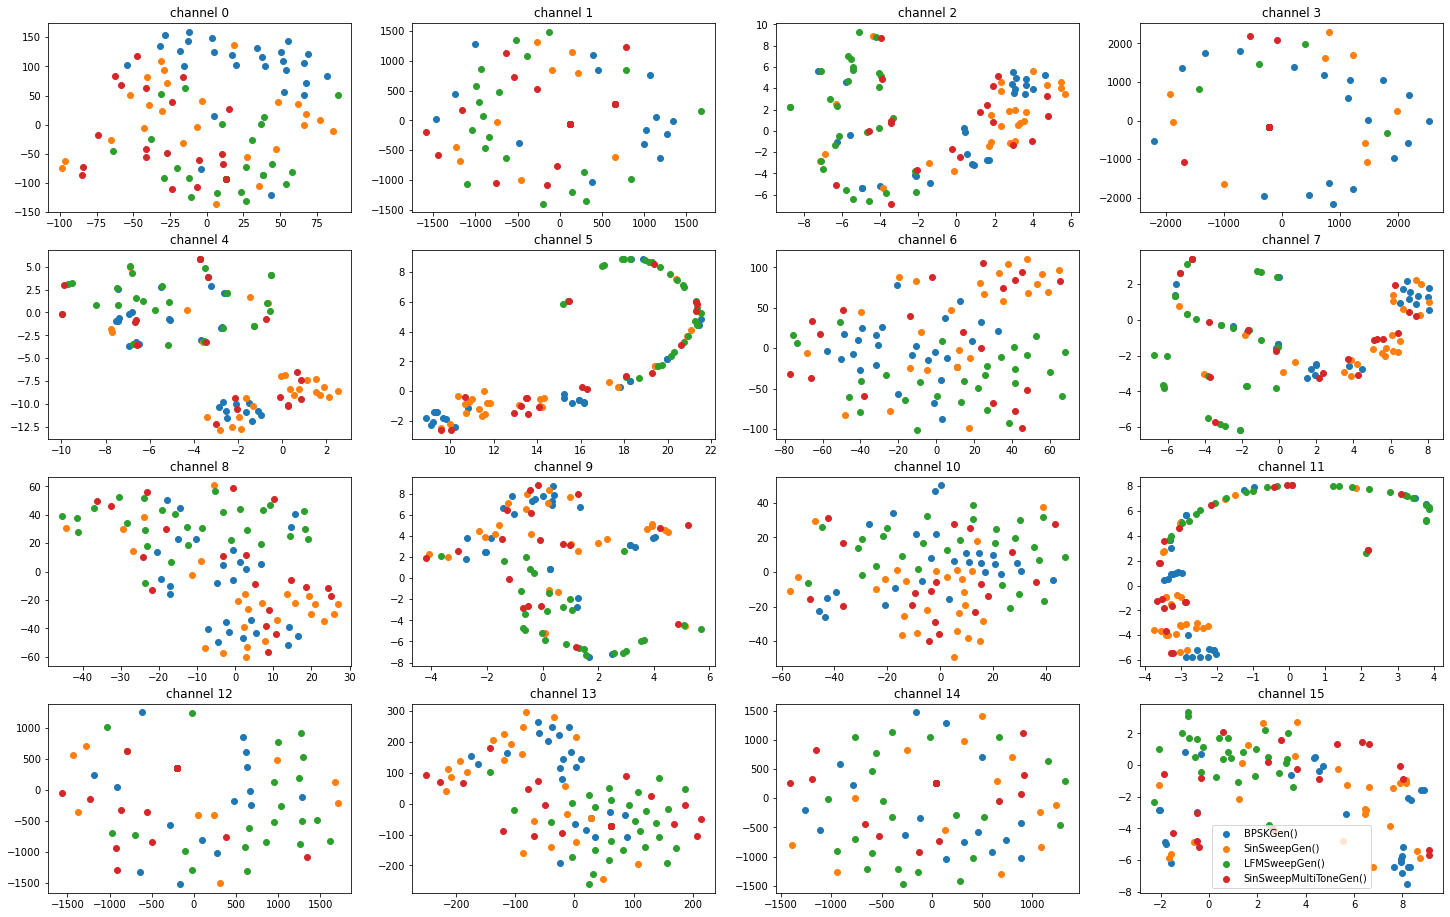

In [5]:
model.tsne_plots(test_ds, device)